# WM 2026 — Live-Update: Tabellen, nächste Spiele & neue Titelchancen

**Begleit-Notebook zu** *Soccer Analytics with Machine Learning* (O'Reilly, 2026).

Dieses Notebook nimmt die **echten WM-2026-Ergebnisse** (sobald gespielt) und rechnet
laufend alles neu:

1. **Aktuelle Gruppentabellen** aus den bereits gespielten Spielen.
2. **Prognose der nächsten Spiele** — Sieg/Remis/Niederlage + wahrscheinlichstes Ergebnis.
3. **Das offizielle K.-o.-Bracket** (Achtelfinale der 32 = Round of 32 → Finale),
   das in `data/wc2026_fixtures.csv` hinterlegt ist, inkl. korrekter Zuordnung der
   acht besten Gruppendritten.
4. **Aktualisierte WM-Chancen** für jedes Team (Achtel-/Viertel-/Halbfinale, Finale,
   Titel) per **Hybrid-Monte-Carlo**: gespielte Ergebnisse stehen fest, der Rest wird
   tausendfach simuliert.

**Datenquelle:** das öffentliche [openfootball](https://github.com/openfootball)-Projekt
(Public Domain). Das Notebook lädt live; bei fehlendem Netz nutzt es den committeten
Snapshot `data/wc2026_results.csv`. Aktualisieren mit `python refresh_data.py`.

> ⚠️ Ergebnisse aus openfootball können vorläufig sein — vor Veröffentlichung gegen
> eine offizielle Quelle prüfen. Stärke-Werte (`STRENGTH`) sind ein Snapshot; siehe
> Abschnitt *„Was muss aktualisiert werden?"*.

## 1. Setup & Modell-Kern

Wir kalibrieren dasselbe Poisson-Tormodell wie in den anderen Notebooks auf 358
echten Länderspielen und definieren die Ergebnis-/Wahrscheinlichkeitsfunktionen.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, urllib.request
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import poisson as pois, nbinom
from scipy.optimize import linear_sum_assignment
import statsmodels.api as sm

rng = np.random.default_rng(2026)
DATA = Path("data")
NAVY, RED, GREEN, AMBER, GREY = "#1E2761", "#B85042", "#2E7D5B", "#E0A040", "#8A8D93"
SCORE_CMAP = LinearSegmentedColormap.from_list("wc", ["#F7F9FC", "#9FB6D6", NAVY])
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.spines.top":False,
    "axes.spines.right":False,"axes.titleweight":"bold","figure.dpi":110,
    "savefig.dpi":150,"savefig.bbox":"tight"})

GROUPS = {
    "A":["Mexico","South Africa","South Korea","Czechia"],"B":["Canada","Bosnia-Herzegovina","Qatar","Switzerland"],
    "C":["Brazil","Morocco","Haiti","Scotland"],"D":["United States","Paraguay","Australia","Türkiye"],
    "E":["Germany","Curacao","Ivory Coast","Ecuador"],"F":["Netherlands","Japan","Sweden","Tunisia"],
    "G":["Belgium","Egypt","Iran","New Zealand"],"H":["Spain","Cape Verde","Saudi Arabia","Uruguay"],
    "I":["France","Senegal","Iraq","Norway"],"J":["Argentina","Algeria","Austria","Jordan"],
    "K":["Portugal","Congo DR","Uzbekistan","Colombia"],"L":["England","Croatia","Ghana","Panama"],
}
TEAMS = [t for g in GROUPS.values() for t in g]; ix = {t:i for i,t in enumerate(TEAMS)}
STRENGTH = {
    "Spain":2165,"Argentina":2120,"France":2100,"England":2055,"Brazil":2025,"Netherlands":2030,
    "Portugal":2010,"Germany":1965,"Belgium":1950,"Croatia":1945,"Uruguay":1930,"Colombia":1915,
    "Morocco":1900,"Japan":1900,"Senegal":1895,"Switzerland":1860,"Norway":1855,"Austria":1850,
    "Ecuador":1840,"Türkiye":1840,"Mexico":1820,"Czechia":1815,"Sweden":1815,"United States":1805,
    "Iran":1800,"Ivory Coast":1800,"Algeria":1795,"South Korea":1790,"Scotland":1780,"Egypt":1780,
    "Canada":1780,"Ghana":1750,"Paraguay":1720,"Australia":1720,"Congo DR":1720,"Bosnia-Herzegovina":1710,
    "Tunisia":1700,"Qatar":1680,"Uzbekistan":1680,"Saudi Arabia":1655,"Iraq":1650,"Panama":1650,
    "South Africa":1640,"Jordan":1600,"Cape Verde":1555,"Curacao":1530,"Haiti":1500,"New Zealand":1500,
    "Italy":1990,"Denmark":1870,"Poland":1825,"Serbia":1820,"Chile":1815,"Russia":1815,"Nigeria":1810,
    "Ukraine":1800,"Greece":1800,"Hungary":1795,"Wales":1790,"Cameroon":1760,"Slovakia":1760,
    "Slovenia":1760,"Romania":1755,"Peru":1750,"Iceland":1740,"Georgia":1735,"Albania":1730,
    "North Macedonia":1720,"Finland":1715,"Costa Rica":1700,"Honduras":1620,"North Korea":1600,
}

def load_matches():
    cols = ["home_team","away_team","home_score","away_score","knockout"]
    m = pd.concat([pd.read_csv(DATA/"worldcup_matches.csv")[cols],
                   pd.read_csv(DATA/"recent_internationals.csv")[cols]], ignore_index=True)
    m = m[m.home_team.isin(STRENGTH) & m.away_team.isin(STRENGTH)].copy()
    m["sdiff"] = m.home_team.map(STRENGTH) - m.away_team.map(STRENGTH)
    m["res"]   = np.sign(m.home_score - m.away_score).astype(int)
    return m
M = load_matches()
gl = pd.DataFrame({"goals": np.r_[M.home_score, M.away_score], "sd": np.r_[M.sdiff, -M.sdiff]})
pois_fit = sm.GLM(gl.goals, sm.add_constant(gl[["sd"]]), family=sm.families.Poisson()).fit()
B0, B1 = pois_fit.params["const"], pois_fit.params["sd"]
alpha  = max(1e-3, (pois_fit.pearson_chi2/pois_fit.df_resid - 1))
dz = sm.add_constant(pd.DataFrame({"abs": M.sdiff.abs()}))
draw_fit = sm.GLM((M.res==0).astype(int), dz, family=sm.families.Binomial()).fit()
def pdraw(absd):
    return float(draw_fit.predict(sm.add_constant(pd.DataFrame({"abs":[absd]}), has_constant="add"))[0])

def lam(a, b, ratings=STRENGTH):
    d = ratings[a]-ratings[b]; return float(np.exp(B0+B1*d)), float(np.exp(B0-B1*d))

def scoreline(a, b, ratings=STRENGTH, dispersion=0.0, maxg=7):
    la, lb = lam(a, b, ratings); g = np.arange(maxg+1)
    def pmf(l):
        if dispersion > 1e-6:
            rr = 1.0/dispersion; return nbinom.pmf(g, rr, rr/(rr+l))
        return pois.pmf(g, l)
    P = np.outer(pmf(la), pmf(lb)); P /= P.sum(); return P, la, lb

def wdl(a, b, ratings=STRENGTH):
    P, _, _ = scoreline(a, b, ratings)
    return np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()   # win1, draw, win2

def modal_score(a, b, ratings=STRENGTH):
    P, la, lb = scoreline(a, b, ratings); n = P.shape[0]; i, j = divmod(int(np.argmax(P)), n)
    return f"{i}:{j}", P[i, j]*100
print(f"Modell kalibriert auf {len(M)} Spielen ·  λ(Gleichstärke) = {np.exp(B0):.2f} Tore")


Modell kalibriert auf 358 Spielen ·  λ(Gleichstärke) = 1.18 Tore


## 2. Aktuelle WM-2026-Daten laden

Erst Live-Download von openfootball (Namens-Normalisierung via `refresh_data.py`),
sonst der lokale Snapshot. Ergebnis ist der komplette Spielplan inkl. der bereits
gespielten Ergebnisse.

In [2]:
URL = "https://raw.githubusercontent.com/openfootball/worldcup.json/master/2026/worldcup.json"
NAME_MAP = {"Czech Republic":"Czechia","Bosnia & Herzegovina":"Bosnia-Herzegovina","Turkey":"Türkiye",
            "USA":"United States","Curaçao":"Curacao","DR Congo":"Congo DR","Korea Republic":"South Korea",
            "IR Iran":"Iran","Côte d'Ivoire":"Ivory Coast"}
def _norm(t): return NAME_MAP.get(t, t)

def load_live():
    try:
        req = urllib.request.Request(URL, headers={"User-Agent":"wc2026-model/1.0"})
        with urllib.request.urlopen(req, timeout=20) as r:
            doc = json.loads(r.read().decode("utf-8"))
        rows = []
        for m in doc["matches"]:
            ft = (m.get("score") or {}).get("ft"); grp = (m.get("group") or "").replace("Group ","").strip()
            rows.append({"date":m.get("date",""),"round":m.get("round",""),"group":grp,
                         "team1":_norm(m["team1"]),"team2":_norm(m["team2"]),
                         "score1": np.nan if not ft else ft[0], "score2": np.nan if not ft else ft[1]})
        return pd.DataFrame(rows), "live von openfootball geladen"
    except Exception as e:
        df = pd.read_csv(DATA/"wc2026_results.csv")
        return df, f"lokaler Snapshot data/wc2026_results.csv (kein Live-Zugriff: {type(e).__name__})"

sched, source = load_live()
sched["score1"] = pd.to_numeric(sched["score1"], errors="coerce")
sched["score2"] = pd.to_numeric(sched["score2"], errors="coerce")
sched["played"] = sched["score1"].notna() & sched["score2"].notna()
grp_played = sched[(sched.group.astype(str).str.len()>0) & sched.group.notna() & sched.played]
n_grp = ((sched.group.astype(str).str.len()>0) & sched.group.notna()).sum()
print(f"Quelle: {source}")
print(f"Spielplan: {len(sched)} Partien · {sched.played.sum()} gespielt "
      f"({len(grp_played)}/{n_grp} Gruppenspiele).")
sched[sched.played].tail(8)[["date","group","team1","score1","score2","team2"]]


Quelle: live von openfootball geladen
Spielplan: 104 Partien · 20 gespielt (20/72 Gruppenspiele).


,date,group,team1,score1,score2,team2
36,2026-06-15,G,Belgium,1.0,1.0,Egypt
37,2026-06-15,G,Iran,2.0,2.0,New Zealand
42,2026-06-15,H,Spain,0.0,0.0,Cape Verde
43,2026-06-15,H,Saudi Arabia,1.0,1.0,Uruguay
48,2026-06-16,I,France,3.0,1.0,Senegal
49,2026-06-16,I,Iraq,1.0,4.0,Norway
54,2026-06-16,J,Argentina,3.0,0.0,Algeria
55,2026-06-16,J,Austria,3.0,1.0,Jordan


## 3. Aktuelle Gruppentabellen

Aus den bereits gespielten Spielen — Punkte, Tordifferenz, Tore. Noch nicht
gespielte Partien fließen hier nicht ein.

In [3]:
def current_tables(sched):
    rows = []
    for g in GROUPS:
        tab = {t: dict(Sp=0, S=0, U=0, N=0, Tore=0, Geg=0, Pkt=0) for t in GROUPS[g]}
        gm = sched[(sched.group==g) & sched.played]
        for _, m in gm.iterrows():
            a, b, x, y = m.team1, m.team2, int(m.score1), int(m.score2)
            if a not in tab or b not in tab: continue
            for t, gf, ga in ((a,x,y),(b,y,x)):
                tab[t]["Sp"]+=1; tab[t]["Tore"]+=gf; tab[t]["Geg"]+=ga
            if x>y:  tab[a]["S"]+=1; tab[a]["Pkt"]+=3; tab[b]["N"]+=1
            elif y>x:tab[b]["S"]+=1; tab[b]["Pkt"]+=3; tab[a]["N"]+=1
            else:    tab[a]["U"]+=1; tab[b]["U"]+=1; tab[a]["Pkt"]+=1; tab[b]["Pkt"]+=1
        order = sorted(GROUPS[g], key=lambda t:(tab[t]["Pkt"], tab[t]["Tore"]-tab[t]["Geg"],
                                                tab[t]["Tore"], STRENGTH[t]), reverse=True)
        for pos, t in enumerate(order, 1):
            d = tab[t]; rows.append({"Gr.":g,"Pos":pos,"Team":t,"Sp":d["Sp"],"S":d["S"],"U":d["U"],
                "N":d["N"],"Tore":f'{d["Tore"]}:{d["Geg"]}',"Diff":d["Tore"]-d["Geg"],"Pkt":d["Pkt"]})
    return pd.DataFrame(rows)

tables = current_tables(sched)
def _hi(row):
    c = "background-color:#d7e9d2" if row.Pos<=2 else ("background-color:#fbf3d6" if row.Pos==3 else "")
    return [c]*len(row)
(tables.style.apply(_hi, axis=1).hide(axis="index")
    .set_caption("Aktuelle Gruppentabellen (grün = Platz 1–2, gelb = Platz 3 / mögl. bester Dritter)"))


Gr.,Pos,Team,Sp,S,U,N,Tore,Diff,Pkt
A,1,Mexico,1,1,0,0,2:0,2,3
A,2,South Korea,1,1,0,0,2:1,1,3
A,3,Czechia,1,0,0,1,1:2,-1,0
A,4,South Africa,1,0,0,1,0:2,-2,0
B,1,Switzerland,1,0,1,0,1:1,0,1
B,2,Canada,1,0,1,0,1:1,0,1
B,3,Bosnia-Herzegovina,1,0,1,0,1:1,0,1
B,4,Qatar,1,0,1,0,1:1,0,1
C,1,Scotland,1,1,0,0,1:0,1,3
C,2,Brazil,1,0,1,0,1:1,0,1


## 4. Prognose der nächsten Spiele

Die nächsten noch nicht gespielten Partien mit Sieg/Remis/Niederlage-Konsens
(Mittel aus Poisson, Negative Binomial, Elo, Colley, PageRank) und dem
wahrscheinlichsten exakten Ergebnis (Poisson).

In [4]:
def wdl_consensus(a, b):
    mods = [wdl(a,b,STRENGTH),                                   # Poisson
            (lambda P: (np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()))(scoreline(a,b,STRENGTH,alpha)[0])]
    for R in (STRENGTH,):                                        # Elo (= Stärke) als Rating
        da = R[a]-R[b]; we = 1/(1+10**(-da/400)); pdr = pdraw(abs(da))
        mods.append(((1-pdr)*we, pdr, (1-pdr)*(1-we)))
    arr = np.array(mods).mean(0); return arr/arr.sum()

def next_matches(sched, k=12):
    up = sched[~sched.played].copy()
    up = up[up.team1.isin(STRENGTH) & up.team2.isin(STRENGTH)]
    up = up.sort_values("date").head(k)
    out = []
    for _, m in up.iterrows():
        a, b = m.team1, m.team2; w, d, l = wdl_consensus(a, b); s, p = modal_score(a, b)
        tag = m.group if isinstance(m.group,str) and m.group else m["round"]
        out.append({"Datum":m.date,"Runde":tag,"Begegnung":f"{a} – {b}",
                    f"P(Sieg 1)":w*100,"P(Remis)":d*100,"P(Sieg 2)":l*100,
                    "wahrsch. Ergebnis":s,"P(Erg.)":p})
    return pd.DataFrame(out)

nxt = next_matches(sched, 12)
(nxt.style.hide(axis="index")
   .format({"P(Sieg 1)":"{:.0f}%","P(Remis)":"{:.0f}%","P(Sieg 2)":"{:.0f}%","P(Erg.)":"{:.0f}%"})
   .background_gradient(cmap="Greens", subset=["P(Sieg 1)"])
   .background_gradient(cmap="Reds",   subset=["P(Sieg 2)"])
   .set_caption("Nächste Spiele — Prognose (Konsens W/U/N + wahrscheinlichstes Ergebnis)"))


Datum,Runde,Begegnung,P(Sieg 1),P(Remis),P(Sieg 2),wahrsch. Ergebnis,P(Erg.)
2026-06-17,L,Ghana – Panama,46%,27%,27%,1:1,13%
2026-06-17,L,England – Croatia,47%,27%,26%,1:0,13%
2026-06-17,K,Uzbekistan – Colombia,16%,24%,59%,0:1,14%
2026-06-17,K,Portugal – Congo DR,64%,23%,13%,1:0,14%
2026-06-18,A,Czechia – South Africa,54%,26%,21%,1:0,13%
2026-06-18,A,Mexico – South Korea,39%,28%,33%,1:1,13%
2026-06-18,B,Switzerland – Bosnia-Herzegovina,51%,26%,23%,1:0,13%
2026-06-18,B,Canada – Qatar,46%,27%,27%,1:1,13%
2026-06-19,D,Türkiye – Paraguay,48%,27%,25%,1:0,13%
2026-06-19,D,United States – Australia,44%,27%,28%,1:1,13%


## 5. Das offizielle K.-o.-Bracket

Das Bracket ist fest vorgegeben (`data/wc2026_fixtures.csv`): Round of 32 mit
Slots wie `1A`, `2B`, `3A/B/C/D/F`, dann R16 → Viertel- → Halbfinale → Finale.
Die acht besten Gruppendritten werden den Slots nach FIFA-Regel (erlaubte Gruppen
je Slot) zugeordnet — hier per gültiger Zuordnung (Matching).

In [5]:
# Round of 32:  (Match-Nr, Slot1, Slot2);  "3:XYZ" = bester Dritter aus einer der Gruppen XYZ
R32 = [(73,"2A","2B"),(74,"1E","3:ABCDF"),(75,"1F","2C"),(76,"1C","2F"),
       (77,"1I","3:CDFGH"),(78,"2E","2I"),(79,"1A","3:CEFHI"),(80,"1L","3:EHIJK"),
       (81,"1D","3:BEFIJ"),(82,"1G","3:AEHIJ"),(83,"2K","2L"),(84,"1H","2J"),
       (85,"1B","3:EFGIJ"),(86,"1J","2H"),(87,"1K","3:DEIJL"),(88,"2D","2G")]
R16 = [(89,74,77),(90,73,75),(91,76,78),(92,79,80),(93,83,84),(94,81,82),(95,86,88),(96,85,87)]
QF  = [(97,89,90),(98,93,94),(99,91,92),(100,95,96)]
SF  = [(101,97,98),(102,99,100)]
FINAL = (101,102)
THIRD_ALLOWED = {m: set(s2.split(":")[1]) for m,s1,s2 in R32 if s2.startswith("3:")}

def assign_thirds(best8):
    """best8: Liste (group, team). -> {Match-Nr: team} per gültigem Matching."""
    slots = list(THIRD_ALLOWED.items())
    cost = np.ones((8,8))*100
    for i,(m,allowed) in enumerate(slots):
        for k,(g,t) in enumerate(best8):
            if g in allowed: cost[i,k] = 0
    ri_, ci = linear_sum_assignment(cost)
    return {slots[i][0]: best8[k][1] for i,k in zip(ri_, ci)}

print("Bracket geladen: 16 R32-Partien, 8 Dritten-Slots, R16/QF/SF/Finale verdrahtet.")


Bracket geladen: 16 R32-Partien, 8 Dritten-Slots, R16/QF/SF/Finale verdrahtet.


## 6. Aktualisierte WM-Chancen (Hybrid-Monte-Carlo)

Gespielte Ergebnisse stehen fest, alle übrigen Gruppenspiele und das komplette
K.-o.-Bracket werden tausendfach simuliert (Poisson-Tormodell). Wir zählen für
jedes Team: Achtelfinale (Round of 32) erreicht, dann R16, Viertel-, Halbfinale,
Finale und Titel.

In [6]:
played_key = {}
for _, m in sched[sched.played].iterrows():
    if isinstance(m.group,str) and m.group and m.team1 in STRENGTH and m.team2 in STRENGTH:
        played_key[(m.group, m.team1, m.team2)] = (int(m.score1), int(m.score2))
fixtures = [(m.group, m.team1, m.team2) for _, m in sched.iterrows()
            if isinstance(m.group,str) and m.group and m.team1 in STRENGTH and m.team2 in STRENGTH]

def _winner(a, b):
    la, lb = lam(a, b); x, y = rng.poisson(la), rng.poisson(lb)
    if x == y:  # K.o.: Elfmeter, leichter Vorteil für das stärkere Team
        return a if rng.random() < 0.5 + (STRENGTH[a]-STRENGTH[b])/4000 else b
    return a if x > y else b

def one_sim():
    st = {g:{t:[0,0,0] for t in GROUPS[g]} for g in GROUPS}   # pts, gd, gf
    for g, a, b in fixtures:
        if (g,a,b) in played_key: x, y = played_key[(g,a,b)]
        else:
            la, lb = lam(a,b); x, y = rng.poisson(la), rng.poisson(lb)
        st[g][a][1]+=x-y; st[g][a][2]+=x; st[g][b][1]+=y-x; st[g][b][2]+=y
        if x>y: st[g][a][0]+=3
        elif y>x: st[g][b][0]+=3
        else: st[g][a][0]+=1; st[g][b][0]+=1
    pos = {}; thirds = []
    for g in GROUPS:
        order = sorted(GROUPS[g], key=lambda t:(st[g][t][0],st[g][t][1],st[g][t][2],rng.random()), reverse=True)
        pos[f"1{g}"], pos[f"2{g}"] = order[0], order[1]
        s = st[g][order[2]]; thirds.append((g, order[2], s[0], s[1], s[2]))
    thirds.sort(key=lambda r:(r[2],r[3],r[4],rng.random()), reverse=True)
    best8 = [(g,t) for g,t,_,_,_ in thirds[:8]]
    tmap = assign_thirds(best8)
    win = {}
    r32_teams = []
    for m, s1, s2 in R32:
        t1 = tmap[m] if s1.startswith("3:") else pos[s1]
        t2 = tmap[m] if s2.startswith("3:") else pos[s2]
        r32_teams += [t1, t2]; win[m] = _winner(t1, t2)
    for grp in (R16, QF, SF):
        for m, m1, m2 in grp: win[m] = _winner(win[m1], win[m2])
    champ = _winner(win[FINAL[0]], win[FINAL[1]])
    stages = {
        "r32": r32_teams,
        "r16": [win[m] for m,_,_ in R32],
        "qf":  [win[m] for m,_,_ in R16],
        "sf":  [win[m] for m,_,_ in QF],
        "final":[win[m] for m,_,_ in SF],
        "champ":[champ],
        "gw":  [pos[f"1{g}"] for g in GROUPS],
    }
    return stages

N_SIM = 8000
keys = ["r32","r16","qf","sf","final","champ","gw"]
cnt = {k: np.zeros(len(TEAMS)) for k in keys}
for _ in range(N_SIM):
    s = one_sim()
    for k in keys:
        for t in s[k]: cnt[k][ix[t]] += 1

prob = pd.DataFrame({"Team": TEAMS, "Stärke":[STRENGTH[t] for t in TEAMS]})
prob["Achtelfinale (R32)"] = cnt["r32"]/N_SIM*100
prob["R16"]   = cnt["r16"]/N_SIM*100
prob["Viertelfinale"] = cnt["qf"]/N_SIM*100
prob["Halbfinale"]    = cnt["sf"]/N_SIM*100
prob["Finale"]        = cnt["final"]/N_SIM*100
prob["Titel"]         = cnt["champ"]/N_SIM*100
prob = prob.sort_values("Titel", ascending=False).reset_index(drop=True)
print(f"{N_SIM:,} Simulationen abgeschlossen.")


8,000 Simulationen abgeschlossen.


### 6.1 Wahrscheinlichkeiten je Team (Top 16)

In [7]:
pcols = ["Achtelfinale (R32)","R16","Viertelfinale","Halbfinale","Finale","Titel"]
(prob.head(16).style.hide(axis="index")
   .format({**{c:"{:.1f}%" for c in pcols}, "Stärke":"{:.0f}"})
   .background_gradient(cmap="YlOrRd", subset=["Titel"])
   .background_gradient(cmap="Blues",  subset=["Achtelfinale (R32)","Viertelfinale"])
   .set_caption(f"Aktualisierte Turnier-Wahrscheinlichkeiten · {N_SIM:,} Simulationen (gespielte Ergebnisse fix)"))


Team,Stärke,Achtelfinale (R32),R16,Viertelfinale,Halbfinale,Finale,Titel
Spain,2165,95.6%,69.1%,51.7%,40.5%,27.5%,18.3%
Argentina,2120,99.9%,69.6%,53.9%,38.6%,24.8%,14.6%
France,2100,99.7%,76.5%,52.4%,36.8%,21.9%,13.3%
England,2055,95.2%,67.1%,44.2%,27.4%,15.9%,9.0%
Brazil,2025,95.8%,57.8%,37.5%,21.5%,11.7%,5.9%
Netherlands,2030,90.8%,55.3%,37.2%,21.2%,11.1%,5.5%
Portugal,2010,93.0%,60.7%,37.8%,20.2%,11.5%,5.2%
Germany,1965,99.5%,61.1%,29.1%,16.5%,7.9%,3.7%
Belgium,1950,93.0%,60.4%,33.9%,15.1%,7.3%,3.2%
Croatia,1945,86.4%,50.0%,25.4%,13.7%,6.6%,2.8%


### 6.2 Titelchancen jetzt — und Veränderung zur Vorhersage vor dem Turnier

Falls vorhanden, vergleichen wir mit dem Konsens aus `model_title_probabilities.csv`
(Vorhersage vor Anpfiff). So sieht man, wer durch die bisherigen Ergebnisse
gewonnen oder verloren hat.

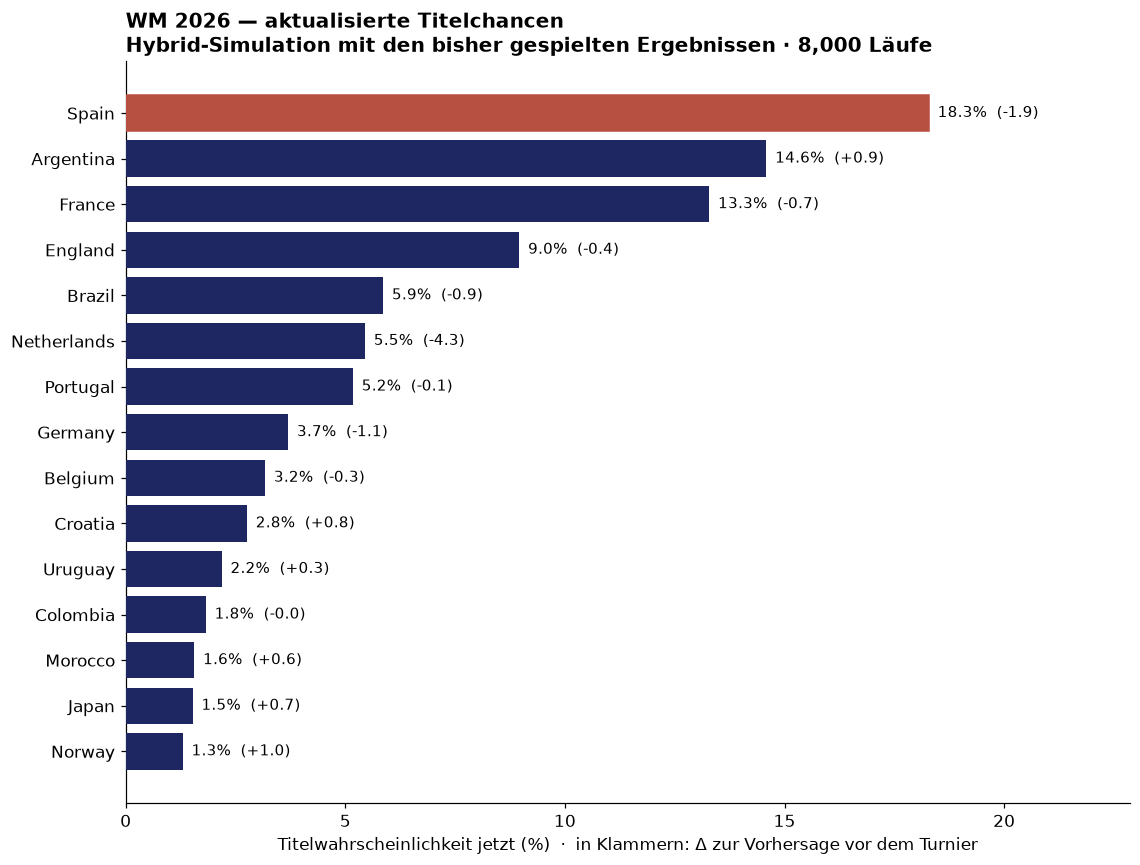

In [8]:
base = None
try:
    b = pd.read_csv("model_title_probabilities.csv")[["team","consensus"]]
    base = dict(zip(b.team, b.consensus))
except Exception:
    pass
top = prob.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.5, 8))
bars = ax.barh(top["Team"], top["Titel"], color=NAVY, zorder=3); bars[-1].set_color(RED)
for i,(t,v) in enumerate(zip(top["Team"], top["Titel"])):
    txt = f"{v:.1f}%"
    if base and t in base:
        d = v - base[t]; txt += f"  ({'+' if d>=0 else ''}{d:.1f})"
    ax.text(v+0.2, i, txt, va="center", fontsize=10)
ax.set_xlabel("Titelwahrscheinlichkeit jetzt (%)  ·  in Klammern: Δ zur Vorhersage vor dem Turnier")
ax.set_title("WM 2026 — aktualisierte Titelchancen\n"
             f"Hybrid-Simulation mit den bisher gespielten Ergebnissen · {N_SIM:,} Läufe", loc="left")
ax.set_xlim(0, top["Titel"].max()*1.25)
plt.tight_layout(); plt.savefig("nb_live_title_odds.png"); plt.show()


## 7. Sobald die Gruppen entschieden sind: das K.-o.-Bracket füllen

Diese Funktion projiziert mit den **aktuell wahrscheinlichsten** Platzierungen
(gespielte Ergebnisse + wahrscheinlichstes Ergebnis der Restspiele) das
Round-of-32 und sagt jede Partie voraus. **Sind alle Gruppenspiele gespielt, ist
das die echte K.-o.-Runde** — derselbe Code, dann ohne Projektion.

In [9]:
def project_bracket(sched):
    st = {g:{t:[0,0,0] for t in GROUPS[g]} for g in GROUPS}
    for g, a, b in fixtures:
        if (g,a,b) in played_key: x, y = played_key[(g,a,b)]
        else:
            P, la, lb = scoreline(a, b); n=P.shape[0]; i,j = divmod(int(np.argmax(P)), n); x,y=i,j
        st[g][a][1]+=x-y; st[g][a][2]+=x; st[g][b][1]+=y-x; st[g][b][2]+=y
        if x>y: st[g][a][0]+=3
        elif y>x: st[g][b][0]+=3
        else: st[g][a][0]+=1; st[g][b][0]+=1
    pos = {}; thirds = []
    for g in GROUPS:
        order = sorted(GROUPS[g], key=lambda t:(st[g][t][0],st[g][t][1],st[g][t][2],STRENGTH[t]), reverse=True)
        pos[f"1{g}"], pos[f"2{g}"] = order[0], order[1]
        s = st[g][order[2]]; thirds.append((g, order[2], s[0], s[1], s[2], STRENGTH[order[2]]))
    thirds.sort(key=lambda r:(r[2],r[3],r[4],r[5]), reverse=True)
    best8 = [(g,t) for g,t,*_ in thirds[:8]]
    tmap = assign_thirds(best8)
    rows = []
    for m, s1, s2 in R32:
        t1 = tmap[m] if s1.startswith("3:") else pos[s1]
        t2 = tmap[m] if s2.startswith("3:") else pos[s2]
        w, d, l = wdl_consensus(t1, t2); s, p = modal_score(t1, t2)
        fav = t1 if w>=l else t2
        rows.append({"R32":m,"Begegnung":f"{t1} – {t2}","P(Sieg 1)":w*100,"P(Remis)":d*100,
                     "P(Sieg 2)":l*100,"Favorit":fav,"wahrsch. Ergebnis":s})
    return pd.DataFrame(rows)

all_grp_done = len(grp_played) == n_grp
bracket = project_bracket(sched)
cap = ("ECHTES Round of 32 (alle Gruppen entschieden)" if all_grp_done
       else "Projiziertes Round of 32 (Stand heute — ändert sich mit den Restspielen)")
(bracket.style.hide(axis="index")
   .format({"P(Sieg 1)":"{:.0f}%","P(Remis)":"{:.0f}%","P(Sieg 2)":"{:.0f}%"})
   .background_gradient(cmap="Greens", subset=["P(Sieg 1)"])
   .background_gradient(cmap="Reds",   subset=["P(Sieg 2)"])
   .set_caption(cap))


R32,Begegnung,P(Sieg 1),P(Remis),P(Sieg 2),Favorit,wahrsch. Ergebnis
73,Mexico – Canada,40%,28%,32%,Mexico,1:1
74,Germany – Scotland,55%,26%,20%,Germany,1:0
75,Netherlands – Morocco,49%,27%,24%,Netherlands,1:0
76,Brazil – Japan,49%,27%,25%,Brazil,1:0
77,France – Türkiye,62%,24%,15%,France,1:0
78,Ivory Coast – Norway,31%,28%,41%,Norway,1:1
79,South Korea – Senegal,26%,27%,47%,Senegal,0:1
80,England – Algeria,62%,24%,15%,England,1:0
81,United States – Qatar,49%,27%,25%,United States,1:0
82,Belgium – Czechia,50%,27%,24%,Belgium,1:0


## 8. Was muss aktualisiert werden?

Damit die Prognosen aktuell und korrekt bleiben:

| Was | Wie | Wann |
|-----|-----|------|
| **Gespielte Ergebnisse** | `python refresh_data.py` (lädt `data/wc2026_results.csv` neu) → Notebook neu ausführen | nach jedem Spieltag |
| **Team-Stärken** (`STRENGTH`) | aktuelle Werte von [eloratings.net](https://www.eloratings.net/) eintragen | vor dem Turnier & bei Bedarf |
| **Playoff-Sieger** (März 2026) | falls abweichend, in `GROUPS`/`STRENGTH` korrigieren (hier: Czechia, Bosnia-Herzegovina, Türkiye, Sweden, Iraq, Congo DR) | einmalig, sobald bekannt |
| **K.-o.-Resultate mit Verlängerung/Elfmeter** | openfootball führt den 90-Minuten-Stand; Sieger eines im Elfmeterschießen entschiedenen Spiels ggf. manuell setzen | in der K.-o.-Phase |
| **Trainingsdaten** (optional) | `python refresh_data.py --training` → `data/*_refreshed.csv` prüfen und ersetzen | selten |
| **Markt-Quoten** (für den Benchmark) | im Suite-Skript auffrischen | optional |

Das meiste erledigt **`refresh_data.py`** automatisch. Nach dem Aktualisieren
einfach *Run All* — Tabellen, Prognosen und Titelchancen rechnen sich neu.

## 9. Können die Datendateien heruntergeladen werden?

**Ja.** Alle Daten stammen aus dem öffentlichen **openfootball**-Projekt (Public
Domain) und werden über `raw.githubusercontent.com` geladen:

* **WM 2026** (Spielplan + Ergebnisse): `worldcup.json/master/2026/worldcup.json`
* **WM 2010–2022** & **EM 2020/2024** (Trainingsdaten): analog je Jahr.

`refresh_data.py` lädt und normalisiert die Namen (z. B. *Czech Republic → Czechia*,
*Turkey → Türkiye*) passend zu den Modellen. Quoten von Wettanbietern und die
Elo-Stärken sind **nicht** frei abrufbar (eloratings.net blockt automatisierte
Zugriffe) und werden im Code gepflegt — siehe `data/SOURCES.md`.

In [10]:
# Direkt aus dem Notebook aktualisieren (lädt data/wc2026_results.csv neu):
import subprocess, sys
res = subprocess.run([sys.executable, "refresh_data.py"], capture_output=True, text=True)
print(res.stdout or res.stderr)
print("Danach dieses Notebook neu ausführen (Run All), um alles zu aktualisieren.")


wc2026_results.csv  ·  104 matches, 20 played (20/72 group games).

Danach dieses Notebook neu ausführen (Run All), um alles zu aktualisieren.


---
*Aus* **Soccer Analytics with Machine Learning** *(O'Reilly, 2026). Daten:
openfootball (Public Domain). Stärke-Werte & Quoten sind ein illustrativer Snapshot —
vor Veröffentlichung auffrischen.*